In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = r"D:\dataset\raw_data"
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 1376 images belonging to 2 classes.
Found 344 images belonging to 2 classes.
Found 430 images belonging to 2 classes.


In [4]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.6388 - loss: 0.6739 - val_accuracy: 0.7762 - val_loss: 0.5008
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8147 - loss: 0.4073 - val_accuracy: 0.8081 - val_loss: 0.4191
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.8503 - loss: 0.3251 - val_accuracy: 0.8285 - val_loss: 0.3332
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.8677 - loss: 0.2891 - val_accuracy: 0.8140 - val_loss: 0.3733
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.9004 - loss: 0.2402 - val_accuracy: 0.8517 - val_loss: 0.3656
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.9251 - loss: 0.1824 - val_accuracy: 0.9012 - val_loss: 0.2023
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9339 - loss: 0.1562 - val_accuracy: 0.8750 - val_loss: 0.3100
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9462 - loss: 0.1416 - val_accuracy: 0.8953 - va

In [7]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

14/14 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.7605 - loss: 0.8880
Test Loss: 0.8879735469818115
Test Accuracy: 0.760465145111084


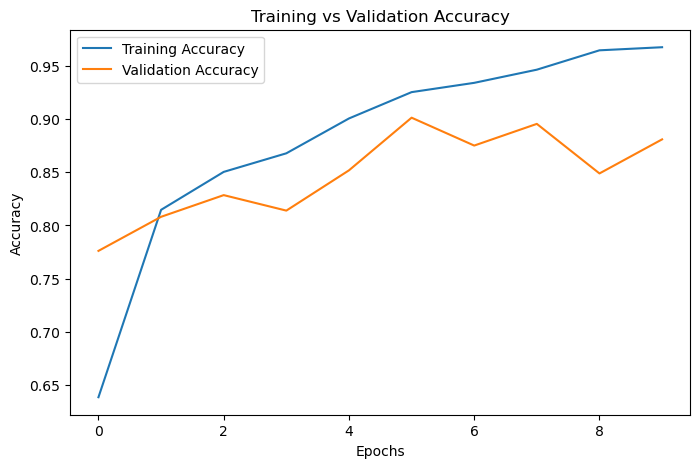

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

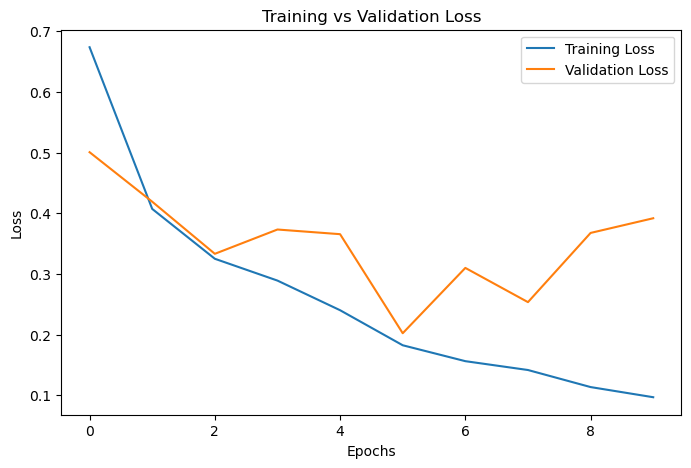

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Observation: Baseline CNN Performance
The CNN model showed strong learning performance, with training accuracy increasing from 63.88% in the first epoch to 96.73% in the final epoch.
The highest validation accuracy of 90.12% was achieved around epoch 6.
After that, validation performance fluctuated while training accuracy continued to increase, indicating mild overfitting.
Overall, the baseline CNN model performed well for classifying ocean images into plastic and no-plastic categories.